<a href="https://colab.research.google.com/github/procoder282/Solubility_ML_project/blob/main/FirstML_Solubility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###My first model

In [31]:
import pandas as pd
df= pd.read_csv('https://raw.githubusercontent.com/dataprofessor/data/refs/heads/master/delaney_solubility_with_descriptors.csv')
df

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.59540,167.850,0.0,0.000000,-2.180
1,2.37650,133.405,0.0,0.000000,-2.000
2,2.59380,167.850,1.0,0.000000,-1.740
3,2.02890,133.405,1.0,0.000000,-1.480
4,2.91890,187.375,1.0,0.000000,-3.040
...,...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000,1.144
1140,3.42130,286.114,2.0,0.333333,-4.925
1141,3.60960,308.333,4.0,0.695652,-3.893
1142,2.56214,354.815,3.0,0.521739,-3.790


###DATA SEPERATION into x and y

In [32]:
y=df['logS']
y

,logS
0,-2.180
1,-2.000
2,-1.740
3,-1.480
4,-3.040
...,...
1139,1.144
1140,-4.925
1141,-3.893
1142,-3.790


In [33]:
X = df.drop('logS',axis=1)
X

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
0,2.59540,167.850,0.0,0.000000
1,2.37650,133.405,0.0,0.000000
2,2.59380,167.850,1.0,0.000000
3,2.02890,133.405,1.0,0.000000
4,2.91890,187.375,1.0,0.000000
...,...,...,...,...
1139,1.98820,287.343,8.0,0.000000
1140,3.42130,286.114,2.0,0.333333
1141,3.60960,308.333,4.0,0.695652
1142,2.56214,354.815,3.0,0.521739


###data splitting

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
643,3.61260,296.410,0.0,0.272727
722,6.48760,226.448,13.0,0.000000
570,3.15380,284.746,1.0,0.600000
66,0.77880,74.123,2.0,0.000000
1002,1.82140,102.177,3.0,0.000000
...,...,...,...,...
1044,2.82960,253.305,1.0,0.631579
1095,2.10750,218.322,3.0,0.000000
1130,4.14820,335.282,7.0,0.260870
860,4.25720,275.179,4.0,0.352941


In [35]:
X_test

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion
218,1.55740,102.177,3.0,0.000000
809,5.20590,345.653,4.0,0.571429
501,4.18090,339.218,4.0,0.545455
649,2.05760,286.349,4.0,0.315789
323,0.72822,146.153,0.0,0.909091
...,...,...,...,...
361,-0.50840,59.068,0.0,0.000000
292,1.94750,116.204,3.0,0.000000
1119,2.16090,257.437,3.0,0.000000
557,3.36680,138.254,0.0,0.000000


**Model building**
###LINEAR REGRESSION

In [36]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [37]:
y_lr_train_pred =lr.predict(X_train)
y_lr_test_pred = lr.predict(X_test)


In [38]:
print(y_lr_train_pred,y_lr_test_pred)

[ -4.47026156  -5.88839323  -4.22029229  -0.79352323  -1.73062942
  -1.26187649  -1.43969557  -2.36087206  -2.77481055  -2.23755209
  -4.15424648  -8.49226359  -4.26355722  -1.5773174   -2.61749814
  -0.72935686  -3.18513222  -3.71048234  -1.57995763  -5.11539503
  -1.90340063  -4.18841892  -4.85523085  -2.13317387  -3.34701685
  -3.45842365  -3.73715663  -3.61882675  -3.02530867  -2.82178231
  -1.54861269  -2.73630968  -1.79353838  -6.49056433  -2.19068424
  -4.10802907  -2.7303035   -2.28598248  -2.60739155  -3.64519507
  -2.65218678  -4.35285798   1.91721982  -3.70871993  -3.50138017
  -2.71898539  -4.77720737  -3.38184768  -1.71815824  -2.79713356
  -5.26774517  -2.96884167  -2.27709013  -2.76017539  -2.12748391
  -2.3140745   -7.74681081  -3.21253144  -1.76376134  -4.17337487
  -2.93249251  -0.51506669  -3.06834756  -0.72788913  -4.05296417
  -2.03616338  -2.67036427  -6.08064174  -5.49773266  -2.9647599
  -2.96100034  -2.60084617  -0.6827446   -4.3585946   -4.0043512
  -0.7973892

In [39]:
from sklearn.metrics import  mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train,y_lr_train_pred)
lr_train_r2 = r2_score(y_train,y_lr_train_pred)

lr_test_mse = mean_squared_error(y_test,y_lr_test_pred)
lr_test_r2 = r2_score(y_test,y_lr_test_pred)


In [40]:
lr_train_mse

1.0139894491573003

In [41]:
lr_test_r2

0.7705650058569232

In [42]:
lr_test_mse

0.9990844407075306

In [43]:
lr_test_r2

0.7705650058569232

###Random forest

In [44]:
from sklearn.ensemble import  RandomForestRegressor

In [45]:
rf = RandomForestRegressor(max_depth=2,random_state=42)

In [46]:
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=2, random_state=42)

In [47]:
y_rf_train_pred =rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)


In [48]:
from sklearn.metrics import  mean_squared_error, r2_score
rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_train_r2 = r2_score(y_train,y_rf_train_pred)

rf_test_mse = mean_squared_error(y_test,y_rf_test_pred)
rf_test_r2 = r2_score(y_test,y_rf_test_pred)

In [49]:
rf_res = pd.DataFrame(['Random forest',rf_train_mse,rf_train_r2,rf_test_mse,rf_test_r2]).transpose()
rf_res.columns = ['method','training MSE','Training R2','Test MSE','Test R2']
rf_res

,method,training MSE,Training R2,Test MSE,Test R2
0,Random forest,1.050251,0.76127,1.046995,0.759562


In [50]:
lr_res = pd.DataFrame(['Linear Regression',lr_train_mse,lr_train_r2,lr_test_mse,lr_test_r2]).transpose()
lr_res.columns = ['method','training MSE','Training R2','Test MSE','Test R2']
lr_res

,method,training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,1.013989,0.769513,0.999084,0.770565


In [51]:
df_models = pd.concat([lr_res,rf_res],axis = 0)
df_models

,method,training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,1.013989,0.769513,0.999084,0.770565
0,Random forest,1.050251,0.76127,1.046995,0.759562


In [52]:
df_models.reset_index(drop="True")

,method,training MSE,Training R2,Test MSE,Test R2
0,Linear Regression,1.013989,0.769513,0.999084,0.770565
1,Random forest,1.050251,0.76127,1.046995,0.759562


Text(0.5, 0, 'Actual LogS')

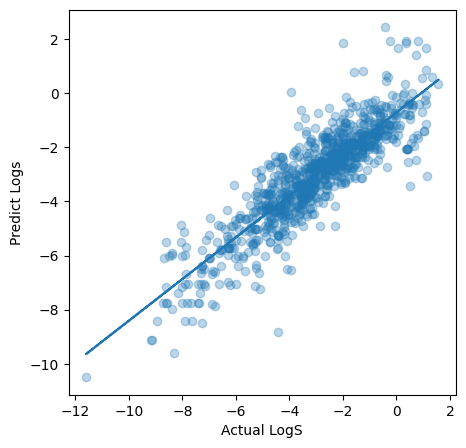

In [53]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=[5,5])
plt.scatter(x=y_train,y=y_lr_train_pred,alpha=0.3)

m = np.polyfit(y_train,y_lr_train_pred, 1)
l = np.poly1d(m)

plt.plot(y_train,l(y_train))
plt.ylabel('Predict Logs')
plt.xlabel('Actual LogS')

Text(0.5, 0, 'Actual LogS')

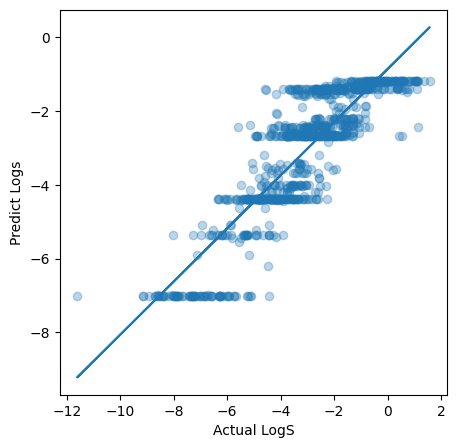

In [54]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=[5,5])
plt.scatter(x=y_train,y=y_rf_train_pred,alpha=0.3)

m = np.polyfit(y_train,y_rf_train_pred, 1)
l = np.poly1d(m)

plt.plot(y_train,l(y_train))
plt.ylabel('Predict Logs')
plt.xlabel('Actual LogS')